In [1]:
import yfinance as yf
import datetime
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import acf

import random

import utils

from tqdm import tqdm

In [2]:
spy = yf.Ticker('NVDA')


In [3]:
print(utils.vwap(spy))

102.76666666666667


In [4]:
options_chain = spy.option_chain('2024-08-09')

In [5]:
calls = options_chain[0]
puts = options_chain[1]

In [13]:
calls[(calls['strike']<1.2*utils.vwap(spy)) & (calls['strike']>(1/1.2)*utils.vwap(spy))]

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
12,NVDA240809C00086000,2024-08-08 15:12:52+00:00,86.0,15.75,16.95,17.10,0.700000,4.651162,58,208,1.093755,True,REGULAR,USD
13,NVDA240809C00087000,2024-08-08 15:06:59+00:00,87.0,15.55,16.00,16.10,2.600000,20.077223,36,366,1.117192,True,REGULAR,USD
14,NVDA240809C00088000,2024-08-08 14:45:40+00:00,88.0,13.90,15.00,15.15,1.599999,13.008125,60,626,1.113286,True,REGULAR,USD
15,NVDA240809C00089000,2024-08-08 14:26:37+00:00,89.0,12.40,13.90,14.00,2.139999,20.857693,100,575,0.781252,True,REGULAR,USD
16,NVDA240809C00090000,2024-08-08 15:24:34+00:00,90.0,12.95,13.05,13.15,3.750000,40.760870,1402,3580,1.023442,True,REGULAR,USD
17,NVDA240809C00091000,2024-08-08 15:11:40+00:00,91.0,10.92,11.85,11.95,1.570000,16.791440,93,895,0.000010,True,REGULAR,USD
18,NVDA240809C00092000,2024-08-08 15:10:57+00:00,92.0,10.10,11.10,11.20,2.450000,32.026146,290,1279,0.953125,True,REGULAR,USD
19,NVDA240809C00093000,2024-08-08 15:21:35+00:00,93.0,9.42,9.65,9.75,2.730000,40.807175,226,3065,0.000010,True,REGULAR,USD
20,NVDA240809C00094000,2024-08-08 15:24:16+00:00,94.0,9.02,8.95,9.05,3.170001,53.911580,258,965,0.515630,True,REGULAR,USD
21,NVDA240809C00095000,2024-08-08 15:25:05+00:00,95.0,8.15,8.20,8.35,2.999999,58.252415,3201,5898,0.843752,True,REGULAR,USD


In [14]:
puts[(puts['strike']<1.2*utils.vwap(spy)) & (puts['strike']>(1/1.2)*utils.vwap(spy))]

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
12,NVDA240809P00086000,2024-08-08 15:14:47+00:00,86.0,0.05,0.05,0.06,-0.120000,-70.588234,1581.0,6847,1.167973,False,REGULAR,USD
13,NVDA240809P00087000,2024-08-08 15:19:43+00:00,87.0,0.07,0.05,0.06,-0.140000,-66.666664,1996.0,3310,1.101567,False,REGULAR,USD
14,NVDA240809P00088000,2024-08-08 15:24:41+00:00,88.0,0.07,0.06,0.07,-0.170000,-68.000000,4603.0,6497,1.066411,False,REGULAR,USD
15,NVDA240809P00089000,2024-08-08 15:20:24+00:00,89.0,0.10,0.09,0.10,-0.220000,-68.750000,3153.0,10531,1.066411,False,REGULAR,USD
16,NVDA240809P00090000,2024-08-08 15:23:52+00:00,90.0,0.10,0.10,0.11,-0.290000,-74.358980,33313.0,64438,1.015630,False,REGULAR,USD
17,NVDA240809P00091000,2024-08-08 15:20:46+00:00,91.0,0.15,0.11,0.12,-0.360000,-70.588234,5384.0,4395,0.960938,False,REGULAR,USD
18,NVDA240809P00092000,2024-08-08 15:24:49+00:00,92.0,0.15,0.14,0.15,-0.490000,-76.562490,7919.0,8088,0.933594,False,REGULAR,USD
19,NVDA240809P00093000,2024-08-08 15:25:25+00:00,93.0,0.18,0.18,0.19,-0.650000,-78.313255,15352.0,11334,0.908204,False,REGULAR,USD
20,NVDA240809P00094000,2024-08-08 15:25:25+00:00,94.0,0.23,0.22,0.23,-0.760000,-76.767680,14197.0,13006,0.871095,False,REGULAR,USD
21,NVDA240809P00095000,2024-08-08 15:25:53+00:00,95.0,0.28,0.28,0.30,-0.950000,-77.235780,64808.0,40000,0.847658,False,REGULAR,USD


In [11]:
cost_of_spread = -(
    calls[calls['strike']==910]['lastPrice'].iloc[0] - calls[calls['strike']==905]['lastPrice'].iloc[0]
) - (
    puts[puts['strike']==915]['lastPrice'].iloc[0] - puts[puts['strike']==920]['lastPrice'].iloc[0]
)

In [12]:
cost_of_spread

6.869999999999999

In [28]:
odds_across_spreads = np.zeros(len(range(850,950,5)))

for index, bottom_strike in enumerate(range(850,950,5)):
    cost_of_spread = (
        calls[calls['strike']==bottom_strike]['lastPrice'].iloc[0] - calls[calls['strike']==(bottom_strike+5)]['lastPrice'].iloc[0]
    ) + (
        puts[puts['strike']==(bottom_strike+15)]['lastPrice'].iloc[0] - puts[puts['strike']==(bottom_strike+10)]['lastPrice'].iloc[0]
    )
    if odds_calculator(cost_of_spread, 10, 5, transaction_cost = 0, num_legs = 4)>0:
        odds_across_spreads[index] = odds_calculator(cost_of_spread, 10, 5, transaction_cost = 0, num_legs = 4)
    else:
        odds_across_spreads[index] = 0


In [29]:
odds_across_spreads

array([0.   , 0.166, 0.068, 0.004, 0.   , 0.054, 0.11 , 0.046, 0.18 ,
       0.248, 0.148, 0.374, 0.14 , 0.02 , 0.046, 0.484, 0.19 , 0.   ,
       0.216, 0.   ])

In [30]:
odds_across_spreads = odds_across_spreads/sum(odds_across_spreads)

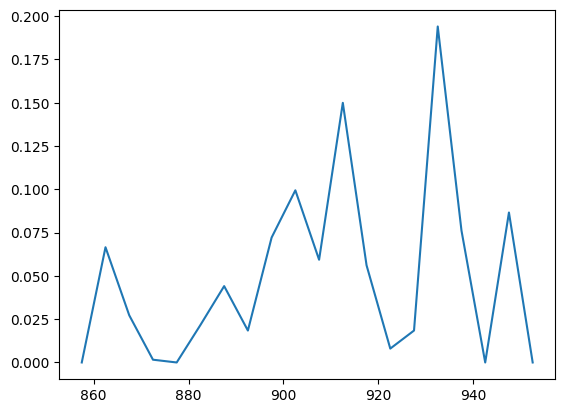

In [33]:
plt.plot(np.arange(850,950,5)+7.5, odds_across_spreads)

In [67]:
odds_across_spreads[4]

0.22522522522522526

In [68]:
odds_across_spreads[5]

0.1936936936936938

In [35]:
puts

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY240227P00423000,2024-02-27 15:36:57+00:00,423.0,0.01,0.00,0.01,0.00,0.000000,5.0,186.0,1.062505,False,REGULAR,USD
1,SPY240227P00424000,2024-02-27 14:46:33+00:00,424.0,0.01,0.00,0.01,0.00,0.000000,1.0,20.0,1.062505,False,REGULAR,USD
2,SPY240227P00425000,2024-02-22 16:35:47+00:00,425.0,0.02,0.00,0.01,0.00,0.000000,1.0,8.0,1.031255,False,REGULAR,USD
3,SPY240227P00427000,2024-02-21 17:23:59+00:00,427.0,0.03,0.00,0.01,0.00,0.000000,NaN,1.0,1.031255,False,REGULAR,USD
4,SPY240227P00428000,2024-02-22 18:51:47+00:00,428.0,0.02,0.00,0.01,0.00,0.000000,210.0,213.0,1.000005,False,REGULAR,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,SPY240227P00512000,2024-02-27 16:42:39+00:00,512.0,6.33,6.18,6.46,0.26,4.283357,62.0,96.0,0.211922,True,REGULAR,USD
83,SPY240227P00515000,2024-02-27 16:03:51+00:00,515.0,8.91,9.00,9.41,0.00,0.000000,77.0,36.0,0.269539,True,REGULAR,USD
84,SPY240227P00520000,2024-02-27 16:30:53+00:00,520.0,14.04,13.98,14.32,0.16,1.152737,6.0,2.0,0.347663,True,REGULAR,USD
85,SPY240227P00525000,2024-02-26 21:13:22+00:00,525.0,19.22,18.96,19.41,0.00,0.000000,16.0,0.0,0.467290,True,REGULAR,USD


In [80]:
ticker = yf.Ticker('SPY')


end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(59)


ticker_hist = ticker.history(interval = '2m', start = start_date ,end=end_date)

ticker_hist = ticker_hist.reset_index()

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

counts, bin_edges = np.histogram(ticker_hist['logReturns'], bins=100)

In [40]:
spy = yf.Ticker('SPY')


end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(59)


spy_hist = spy.history(interval = '2m', start = start_date ,end=end_date)

spy_hist = spy_hist.reset_index()

spy_hist['Date'] = spy_hist.apply(lambda row: row['Datetime'].date(), axis=1)
spy_hist['Time'] = spy_hist.apply(lambda row: row['Datetime'].time(), axis=1)


spy_hist['logClose'] = np.log(spy_hist['Close'])
spy_hist['logOpen'] = np.log(spy_hist['Open'])

spy_hist['logReturns'] = spy_hist['logClose'] - spy_hist['logOpen']

In [41]:
merged_dfs = pd.merge(spy_hist, ticker_hist, on = ['Datetime'])

In [44]:
merged_dfs['logReturns_x_shifted'] = merged_dfs['logReturns_x'].shift(10)
merged_dfs['logReturns_y_shifted'] = merged_dfs['logReturns_y'].shift(10)


In [56]:
np.exp(-np.abs(bin_edges - np.mean(bin_edges)))

array([0.97557048, 0.97605317, 0.97653611, 0.97701928, 0.97750269,
       0.97798633, 0.97847022, 0.97895435, 0.97943872, 0.97992332,
       0.98040817, 0.98089325, 0.98137858, 0.98186415, 0.98234995,
       0.982836  , 0.98332229, 0.98380882, 0.98429558, 0.98478259,
       0.98526984, 0.98575734, 0.98624507, 0.98673304, 0.98722126,
       0.98770972, 0.98819841, 0.98868735, 0.98917654, 0.98966596,
       0.99015563, 0.99064554, 0.99113569, 0.99162608, 0.99211672,
       0.9926076 , 0.99309872, 0.99359009, 0.99408169, 0.99457355,
       0.99506564, 0.99555798, 0.99605056, 0.99654339, 0.99703646,
       0.99752977, 0.99802333, 0.99851713, 0.99901117, 0.99950546,
       1.        , 0.99950546, 0.99901117, 0.99851713, 0.99802333,
       0.99752977, 0.99703646, 0.99654339, 0.99605056, 0.99555798,
       0.99506564, 0.99457355, 0.99408169, 0.99359009, 0.99309872,
       0.9926076 , 0.99211672, 0.99162608, 0.99113569, 0.99064554,
       0.99015563, 0.98966596, 0.98917654, 0.98868735, 0.98819

In [76]:
np.mean(ticker_hist['logReturns'])

np.float64(-2.9184036225425183e-05)

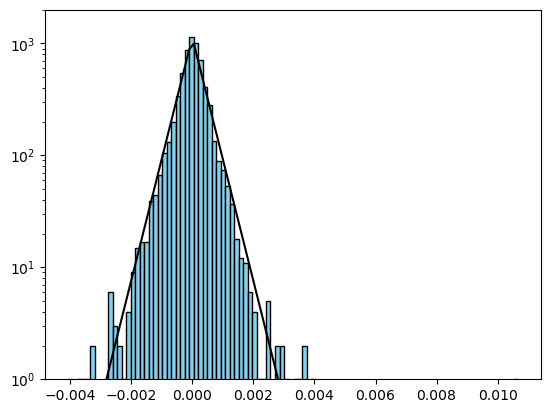

In [85]:
plt.bar(x=bin_edges[:-1], height=counts, width=np.diff(bin_edges), align='edge', fc='skyblue', ec='black')
plt.plot(bin_edges, np.max(counts)*np.exp(-2500*np.abs(bin_edges - np.mean(ticker_hist['logReturns']))), color='black')
plt.yscale('log')
plt.ylim((1,2000))
plt.show()

In [52]:
def simulate_outcomes(ticker, target_date, distribution, weights):
    """
    simulates the outcomes of a stock price by randomly drawing from the distribution of 2 minute returns between now and a target datetime object.
    currently, distribution is empirical, but advances could be made by implementing a (truncated) levy distro

    parameters:
        ticker: yfinance.Ticker object
        target_date: datetime object identifying the end time
        distribution: range of log returns to draw
        weights: probability of hitting a given bin_edge (the cdf)
    """

    #get time between
    current_date = datetime.datetime.now()
    time_delta = target_date - current_date

    intervals_to_expiry = time_delta.days * (15 + 6*30) + np.min([15 + 6*30, (time_delta.seconds//120)])
    print(intervals_to_expiry)
    log_returns_deviation = np.zeros(100000)

    
    for r in tqdm(range(len(log_returns_deviation))):
        for i in range(intervals_to_expiry):
            index_list = np.where(random.uniform(0,1)>weights)[0]
            if len(index_list)==0:
                index = 0
            else:
                index = np.max(index_list) + 1
            log_returns_deviation[r] += distribution[index]
    
    current_price = vwap(ticker)

    return np.exp(np.log(current_price) + log_returns_deviation)

In [ ]:


outcomes = simulate_outcomes(spy, datetime.datetime(2024,3,22,16,0,0), assumed_values, np.cumsum(counts)/np.sum(counts))

In [45]:
merged_dfs[['logReturns_x', 'logReturns_y', 'logReturns_x_shifted', 'logReturns_y_shifted']].corr()

,logReturns_x,logReturns_y,logReturns_x_shifted,logReturns_y_shifted
logReturns_x,1.000000,0.187155,-0.024676,-0.014347
logReturns_y,0.187155,1.000000,0.005876,0.003986
logReturns_x_shifted,-0.024676,0.005876,1.000000,0.187211
logReturns_y_shifted,-0.014347,0.003986,0.187211,1.000000


In [23]:
np.corrcoef(spy_hist['logReturns'], ticker_hist['logReturns'])

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 6414 and the array at index 1 has size 6418

In [20]:
spy_hist

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Date,Time,logClose,logOpen,logReturns
0,2024-06-21 09:30:00-04:00,544.400024,544.551270,544.015015,544.460022,2152695,1.759,0.0,0.0,2024-06-21,09:30:00,6.299795,6.299684,0.000110
1,2024-06-21 09:32:00-04:00,544.440002,544.719971,544.280029,544.280029,308911,0.000,0.0,0.0,2024-06-21,09:32:00,6.299464,6.299758,-0.000294
2,2024-06-21 09:34:00-04:00,544.280029,544.820007,544.280029,544.789978,280166,0.000,0.0,0.0,2024-06-21,09:34:00,6.300400,6.299464,0.000936
3,2024-06-21 09:36:00-04:00,544.789978,544.859985,544.530029,544.664978,402096,0.000,0.0,0.0,2024-06-21,09:36:00,6.300171,6.300400,-0.000229
4,2024-06-21 09:38:00-04:00,544.650024,544.739990,544.150024,544.320007,248243,0.000,0.0,0.0,2024-06-21,09:38:00,6.299537,6.300143,-0.000606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6409,2024-08-08 11:52:00-04:00,527.500000,527.750000,527.388428,527.710022,69452,0.000,0.0,0.0,2024-08-08,11:52:00,6.268547,6.268149,0.000398
6410,2024-08-08 11:54:00-04:00,527.750000,527.879028,527.659973,527.830017,86449,0.000,0.0,0.0,2024-08-08,11:54:00,6.268774,6.268623,0.000152
6411,2024-08-08 11:56:00-04:00,527.809875,527.919983,527.599976,527.780029,123017,0.000,0.0,0.0,2024-08-08,11:56:00,6.268680,6.268736,-0.000057
6412,2024-08-08 11:58:00-04:00,527.820007,528.054993,527.674988,527.674988,184152,0.000,0.0,0.0,2024-08-08,11:58:00,6.268481,6.268755,-0.000275
